# Визуализация данных - географические карты. Анализ ДТП в РФ

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('datasets/dtp201804.csv', encoding="utf-8", delimiter = ";")
df

,reg_code,reg_name,road_code,road_name,road_type,oktmo,address,crash_type_name,crash_date,crash_time,crash_reason,fatalities_amount,victims_amount,vehicles_amount,participants_amount,latitude,longitude
0,46,Московская область,NaN,мкр. Авиационный-Лямцино-ММК,Региональная или межмуниципальная дорога общег...,NaN,"ЦФО, Московская область, Городской округ Домод...",Опрокидывание,20181231,23:55:00,Другие нарушения ПДД водителями,1,0,1,12,55.359795,37.906179
1,53,Оренбургская область,53К-2118000,Обход г. Оренбурга,Региональная или межмуниципальная дорога общег...,5.370100e+07,"ПФО, Оренбургская область, Оренбург",Наезд на препятствие,20181231,23:55:00,Другие нарушения ПДД водителями,1,0,1,2,51.785876,55.186837
2,46,Московская область,А-107,"""Московское малое кольцо"" Икша - Ногинск - Бро...",Федеральная дорога общего пользования,4.660800e+07,"ЦФО, Московская область, Дмитровский район",Опрокидывание,20181231,23:40:00,Превышение установленной скорости движения,1,0,1,2,56.137324,37.458766
3,8,Хабаровский край,А-375,"""Восток"" Хабаровск - Красный Яр - Ариадное - Ч...",Федеральная дорога общего пользования,8.655000e+06,"ДФО, Хабаровский край, Хабаровский район",Наезд на пешехода,20181231,23:20:00,Нахождение на проезжей части без цели её перех...,0,1,1,2,48.467142,135.439112
4,35,Республика Крым,35Н-076,Симферополь - Севастополь - Бахчисарай,Региональная или межмуниципальная дорога общег...,NaN,"ЮФО, Республика Крым, Бахчисарайский район",Наезд на пешехода,20181231,23:00:00,Нарушение правил проезда пешеходного перехода,1,0,1,2,44.744066,33.846538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39081,80,Республика Башкортостан,80Н-069,Аскарово - Альмухаметово - Сибай,Региональная или межмуниципальная дорога общег...,8.060143e+10,"ПФО, Республика Башкортостан, Абзелиловский ра...",Наезд на животное,20180401,1:55:00,Нарушение правил расположения ТС на проезжей ч...,2,0,1,4,53.207200,58.500000
39082,79,Республика Адыгея,NaN,Подъезд к а.Вочепший,Региональная или межмуниципальная дорога общег...,7.963300e+07,"ЮФО, Республика Адыгея, Теучежский район",Наезд на животное,20180401,1:30:00,Другие нарушения ПДД водителями,0,1,1,12,44.465000,39.107200
39083,3,Краснодарский край,Р-217,Подъезд к городу Майкоп от а/д Р-217,Федеральная дорога общего пользования,3.634000e+06,"ЮФО, Краснодарский край, Новокубанский район",Столкновение,20180401,1:00:00,"Выезд на полосу встречного движения в местах, ...",2,0,2,3,44.084400,41.000300
39084,76,Забайкальский край,А-350,Чита - Забайкальск - граница с Китайской Народ...,Федеральная дорога общего пользования,7.665016e+07,"СФО, Забайкальский край, Читинский район, Ново...",Опрокидывание,20180401,0:30:00,Нарушение правил расположения ТС на проезжей ч...,3,1,1,4,51.788900,113.786400


Вам предоставлен набор данных в виде файла dtp201804-1.csv, в котором содержится информация о дорожно-транспортных происшествиях в РФ за 2018 год.
- reg_code - код региона
- reg_name - название региона
- road_code - код трассы
- road_name - направление
- road_type - тип трассы
- oktmo - кодам ОКТМО
- address - адрес
- crash_type_name - тип происшествия
- crash_date - дата происшествия
- crash_time - время происшествия
- crash_reason - причина происшествия
- fatalities_amount - количество смертельных случаев
- victims_amount - количество жертв
- vehicles_amount - количество транспортных средств
- participants_amount - количество участников
- latitude - широта
- longitude - долгота

Для установки библиотек рекомендуется использовать параметр --no-cache-dir.

Пояснение. 
Опция --no-cache-dir в командах pip (менеджере пакетов Python) отключает кэширование загружаемых пакетов. В нашем случае это нужно для экономии места на диске.


In [4]:
pip install --no-cache-dir folium


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Задание 1: Тепловая карта ДТП по регионам России
Показать плотность ДТП в разных регионах.

Использовать folium или plotly для создания тепловой карты.

Доп. анализ: Выделить регионы с наибольшим числом ДТП.

In [32]:
import folium
from folium.plugins import HeatMap

# Создаем карту России с центром в Москве
russia_map = folium.Map(location=[55.751244, 37.618423], zoom_start=4)

# Подготовка данных для тепловой карты
heat_data = [[row['latitude'], row['longitude']] for index, row in df.iterrows()]

# Добавляем тепловой слой
HeatMap(heat_data, radius=13).add_to(russia_map)

# Выводим карту
russia_map

In [7]:
# Анализ регионов с наибольшим числом ДТП
region_stats = df['reg_name'].value_counts().head(10)
print("Топ-10 регионов по количеству ДТП:")
print(region_stats)

Топ-10 регионов по количеству ДТП:
reg_name
Московская область         2764
Краснодарский край         2294
Ленинградская область      1425
Республика Башкортостан    1075
Ставропольский край         956
Ростовская область          948
Москва                      933
Республика Татарстан        876
Владимирская область        841
Красноярский край           803
Name: count, dtype: int64


## Задание 2:  ДТП с жертвами (folium)

Показать участки дорог, где количество смертельных случаев больше 10 человек. 

Добавить количество жертв (число погибших) на карту в виде подписей к маркерам, можно использовать folium.DivIcon для создания текстовых меток. 
Добавьте тултипы - всплывающие сообщения (при наведении), на которых отображается причина происшествия, дата аварии в формате (dd.mm.YYYY), тип происшествия. 

Метод: для folium метод CircleMarker. 


In [8]:
import folium
import pandas as pd

# Фильтруем данные: оставляем только ДТП с количеством смертельных случаев > 10
fatal_accidents = df[df['fatalities_amount'] > 10]

# Проверяем, есть ли такие ДТП
if fatal_accidents.empty:
    print("В данных нет ДТП с количеством смертельных случаев больше 10")
else:
    # Создаем карту России с центром в Москве
    russia_map = folium.Map(location=[55.751244, 37.618423], zoom_start=4)
    
    # Добавляем маркеры для каждого ДТП с жертвами > 10
    for idx, row in fatal_accidents.iterrows():
        # Преобразуем дату из int в строку и затем в формат dd.mm.YYYY
        crash_date_str = str(row['crash_date'])
        crash_date = f"{crash_date_str[6:8]}.{crash_date_str[4:6]}.{crash_date_str[:4]}"
        
        # Создаем всплывающее сообщение (тултип)
        popup_text = (f"<b>Регион:</b> {row['reg_name']}<br>"
                     f"<b>Дата:</b> {crash_date}<br>"
                     f"<b>Время:</b> {row['crash_time']}<br>"
                     f"<b>Тип ДТП:</b> {row['crash_type_name']}<br>"
                     f"<b>Причина:</b> {row['crash_reason']}<br>"
                     f"<b>Погибло:</b> {row['fatalities_amount']}<br>"
                     f"<b>Пострадало:</b> {row['victims_amount']}")
        
        # Создаем метку с количеством жертв
        label = folium.DivIcon(
            html=f'<div style="font-size: 12pt; color: red; font-weight: bold;">{row["fatalities_amount"]}</div>'
        )
        
        # Добавляем маркер на карту
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=popup_text,
            icon=label
        ).add_to(russia_map)
    
    # Выводим карту
    display(russia_map)
    
    # Находим ДТП с максимальным количеством смертельных случаев
    max_fatal = fatal_accidents.loc[fatal_accidents['fatalities_amount'].idxmax()]
    print("\nДТП с максимальным количеством смертельных случаев:")
    print(f"Количество погибших: {max_fatal['fatalities_amount']}")
    print(f"Регион: {max_fatal['reg_name']}")
    crash_date_str = str(max_fatal['crash_date'])
    print(f"Дата: {crash_date_str[6:8]}.{crash_date_str[4:6]}.{crash_date_str[:4]}")
    print(f"Тип ДТП: {max_fatal['crash_type_name']}")
    print(f"Причина: {max_fatal['crash_reason']}")


ДТП с максимальным количеством смертельных случаев:
Количество погибших: 46
Регион: Псковская область
Дата: 22.05.2018
Тип ДТП: Съезд с дороги
Причина: Другие нарушения ПДД водителями


Ответьте на вопросы: какое максимальное число смертельных случаев в данном наборе? в какой области и когда это случилось?

## Задание 3: Причины и типы самых ужастных происшествий
Изменить карту из задания 2, добавить стили для маркеров - отдельные типы происшествий должны быть отображаться отдельным цветов.
В легенде  вывести цвет - тип происшествия. 


In [12]:
unique_types = df['crash_type_name'].unique()
print("Уникальные типы ДТП:")
print(len(unique_types), unique_types)

Уникальные типы ДТП:
18 ['Опрокидывание' 'Наезд на препятствие' 'Наезд на пешехода' 'Столкновение'
 'Наезд на стоящее ТС' 'Съезд с дороги' 'Падение пассажира'
 'Наезд на животное' 'Наезд на велосипедиста' 'Иной вид ДТП'
 'Падение груза'
 'Наезд на лицо, не являющееся участником дорожного движения(иного участника ДТП), осуществляющее несение службы'
 'Отбрасывание предмета(отсоединение колеса)'
 'Наезд на лицо, не являющееся участником дорожного движения(иного участника ДТП), осуществляющее производство работ'
 'Наезд на внезапно возникшее препятствие' 'Наезд на гужевой транспорт'
 'Наезд на лицо, не являющееся участником дорожного движения(иного участника ДТП), осуществляющее какую-либо другую деятельность'
 'Возгорание вследствие технической неисправности движущегося или остановившегося ТС, участвующего в дорожном движении']


In [18]:
from folium.plugins import MarkerCluster

category_mapping = {
    'Столкновение': 'Столкновение',
    'Наезд на препятствие': 'Наезд',
    'Наезд на пешехода': 'Наезд', 
    'Наезд на стоящее ТС': 'Наезд',
    'Наезд на животное': 'Наезд',
    'Наезд на велосипедиста': 'Наезд',
    'Опрокидывание': 'Опрокидывание',
    'Съезд с дороги': 'Опрокидывание',
    # Все остальные относим к "Иной вид ДТП"
}

# Создаем новую колонку с категориями
df['category'] = df['crash_type_name'].apply(lambda x: category_mapping.get(x, 'Иной вид ДТП'))

# Фильтруем данные: оставляем только ДТП с количеством смертельных случаев > 10
fatal_accidents = df[df['fatalities_amount'] > 10]

if fatal_accidents.empty:
    print("В данных нет ДТП с количеством смертельных случаев больше 10")
else:
    # Создаем карту России
    russia_map = folium.Map(location=[55.751244, 37.618423], zoom_start=4)
    
    # Цвета для категорий
    colors = {
        'Столкновение': 'red',
        'Наезд': 'blue',
        'Опрокидывание': 'green',
        'Иной вид ДТП': 'purple'
    }
    
    # Создаем кластеры для каждой категории
    for category, color in colors.items():
        # Фильтруем данные по категории
        category_data = fatal_accidents[fatal_accidents['category'] == category]
        
        # Создаем кластер для категории
        marker_cluster = MarkerCluster(
            name=category,
            overlay=True,
            control=True,
            icon_create_function=None
        )
        
        # Добавляем маркеры в кластер
        for idx, row in category_data.iterrows():
            crash_date_str = str(row['crash_date'])
            crash_date = f"{crash_date_str[6:8]}.{crash_date_str[4:6]}.{crash_date_str[:4]}"
            
            popup_text = (f"<b>Категория:</b> {category}<br>"
                         f"<b>Тип:</b> {row['crash_type_name']}<br>"
                         f"<b>Дата:</b> {crash_date}<br>"
                         f"<b>Причина:</b> {row['crash_reason']}<br>"
                         f"<b>Погибло:</b> {row['fatalities_amount']}<br>"
                         f"<b>Пострадало:</b> {row['victims_amount']}")
            
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=row['fatalities_amount']/2,
                popup=popup_text,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.7,
                weight=1
            ).add_to(marker_cluster)
        
        marker_cluster.add_to(russia_map)
    
    # Добавляем контроль слоев
    folium.LayerControl().add_to(russia_map)
    
    # Добавляем легенду
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 160px; 
                border:2px solid grey; z-index:9999; font-size:12px;
                background-color:white;
                padding: 10px;">
        <b>Категории ДТП:</b><br>
    '''
    for category, color in colors.items():
        legend_html += f'<i style="background:{color}; width:12px; height:12px; display:inline-block;"></i> {category}<br>'
    legend_html += '</div>'
    
    russia_map.get_root().html.add_child(folium.Element(legend_html))
    
    # Выводим карту
    display(russia_map)
    
   

Ответьте на вопросы: каких типов происшествий больше всего? какова основная причина таких происшествий?

🚗💥 НЕ ДЕЛАЙТЕ ТАК! СОБЛЮДАЙТЕ ПДД!

In [33]:
 # Анализ распределения по категориям
print("\nРаспределение ДТП по категориям:")
print(fatal_accidents['category'].value_counts())
    
    # Анализ причин по категориям
print("\nТоп-3 причины для каждой категории:")
for category in colors.keys():
    print(f"\n{category}:")
    print(fatal_accidents[fatal_accidents['category'] == category]['crash_reason'].value_counts().head(5))


Распределение ДТП по категориям:
category
Столкновение     52
Опрокидывание    13
Наезд             9
Name: count, dtype: int64

Топ-3 причины для каждой категории:

Столкновение:
crash_reason
Выезд на полосу встречного движения                   18
Неправильный выбор дистанции                           7
Несоблюдение очередности проезда                       6
Другие нарушения ПДД водителями                        4
Нарушение правил расположения ТС на проезжей части     4
Name: count, dtype: int64

Наезд:
crash_reason
Другие нарушения ПДД водителями                                                                              3
Неправильный выбор дистанции                                                                                 2
Стоянка на проезжей части или обочине без освещения, Несоответствие скорости конкретным условиям движения    1
Неправильный выбор дистанции, Неправильный выбор дистанции                                                   1
Несоответствие скорости конкре

## Задание 4: Анализ ДТП по времени суток

Показать динамику аварийности в течение дня.

Выведите три диаграммы:
1. Распределение ДТП по времени суток:
- Столбчатая диаграмма с количеством аварий для каждого периода: ('Ночь (0-6)', 'Утро (6-12)', 'День (12-18)', 'Вечер (18-24)') - разделение на ночь/утро/день/вечер
- Цветовая кодировка периодов суток

2. Типы ДТП по времени суток:
- Накопительная столбчатая диаграмма - какие типы аварий преобладают в разное время

3. Тяжесть ДТП по часам:
- Линейный график средней тяжести аварий
- Отдельные линии для погибших и пострадавших

Вывести легенду по типам ДТП.


/tmp/ipykernel_91/1826390723.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=df, x='time_period', order=order, palette=palette)


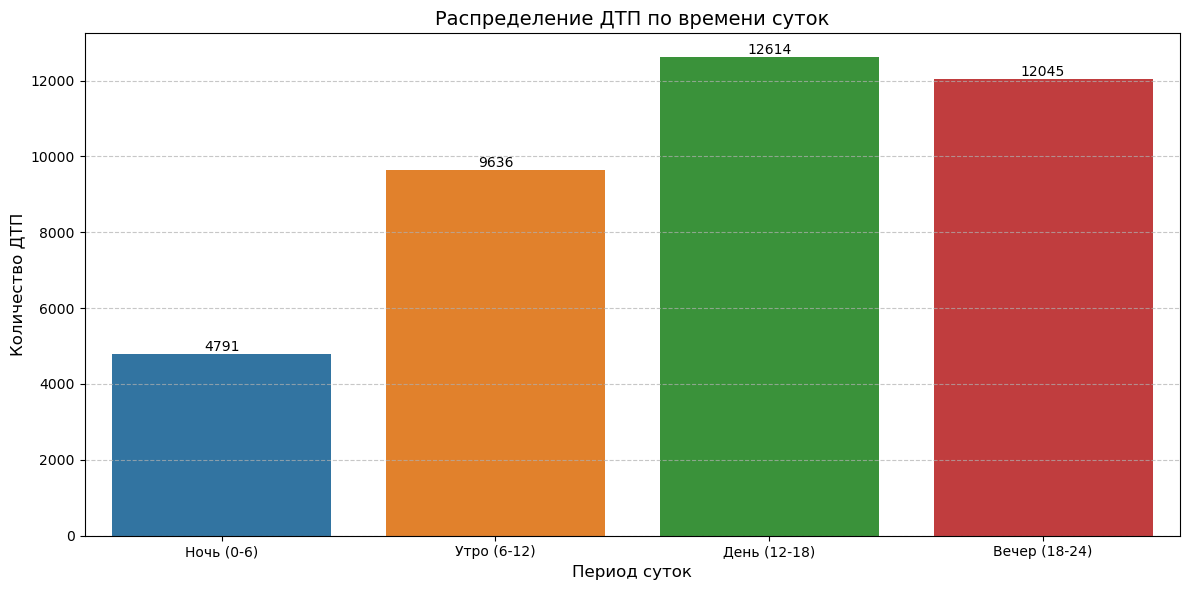

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator

# Преобразуем время в часы
df['hour'] = pd.to_datetime(df['crash_time'], format='%H:%M:%S').dt.hour

# Создаем периоды суток
def get_time_period(hour):
    if 0 <= hour < 6:
        return 'Ночь (0-6)'
    elif 6 <= hour < 12:
        return 'Утро (6-12)'
    elif 12 <= hour < 18:
        return 'День (12-18)'
    else:
        return 'Вечер (18-24)'

df['time_period'] = df['hour'].apply(get_time_period)

# Создаем категории ДТП (как в задании 3)
category_mapping = {
    'Столкновение': 'Столкновение',
    'Наезд на препятствие': 'Наезд',
    'Наезд на пешехода': 'Наезд',
    'Наезд на стоящее ТС': 'Наезд',
    'Наезд на животное': 'Наезд',
    'Наезд на велосипедиста': 'Наезд',
    'Опрокидывание': 'Опрокидывание',
    'Съезд с дороги': 'Опрокидывание'
}
df['category'] = df['crash_type_name'].map(lambda x: category_mapping.get(x, 'Иной вид ДТП'))

# 1. Распределение ДТП по времени суток
plt.figure(figsize=(12, 6))
order = ['Ночь (0-6)', 'Утро (6-12)', 'День (12-18)', 'Вечер (18-24)']
palette = {'Ночь (0-6)': '#1f77b4', 'Утро (6-12)': '#ff7f0e', 
           'День (12-18)': '#2ca02c', 'Вечер (18-24)': '#d62728'}

ax1 = sns.countplot(data=df, x='time_period', order=order, palette=palette)
plt.title('Распределение ДТП по времени суток', fontsize=14)
plt.xlabel('Период суток', fontsize=12)
plt.ylabel('Количество ДТП', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Добавляем значения на столбцы
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

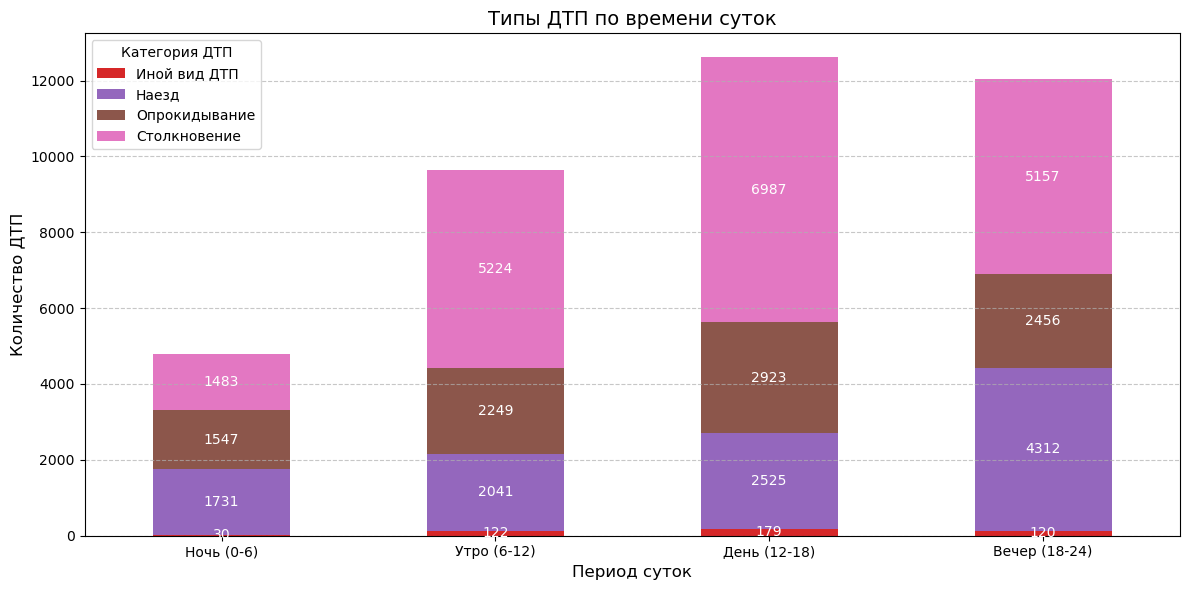

In [23]:
# 2. Типы ДТП по времени суток
plt.figure(figsize=(12, 6))
cross_tab = pd.crosstab(df['time_period'], df['category'])
cross_tab = cross_tab.reindex(order)

ax2 = cross_tab.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#d62728', '#9467bd', '#8c564b', '#e377c2'])
plt.title('Типы ДТП по времени суток', fontsize=14)
plt.xlabel('Период суток', fontsize=12)
plt.ylabel('Количество ДТП', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Категория ДТП')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Добавляем общие значения на столбцы
for rect in ax2.patches:
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()
    
    if height > 0:
        ax2.text(x + width/2., y + height/2., f'{int(height)}', 
                ha='center', va='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()

In [39]:
hourly_stats.loc[0]['fatalities_amount']*2

2.683682771194166

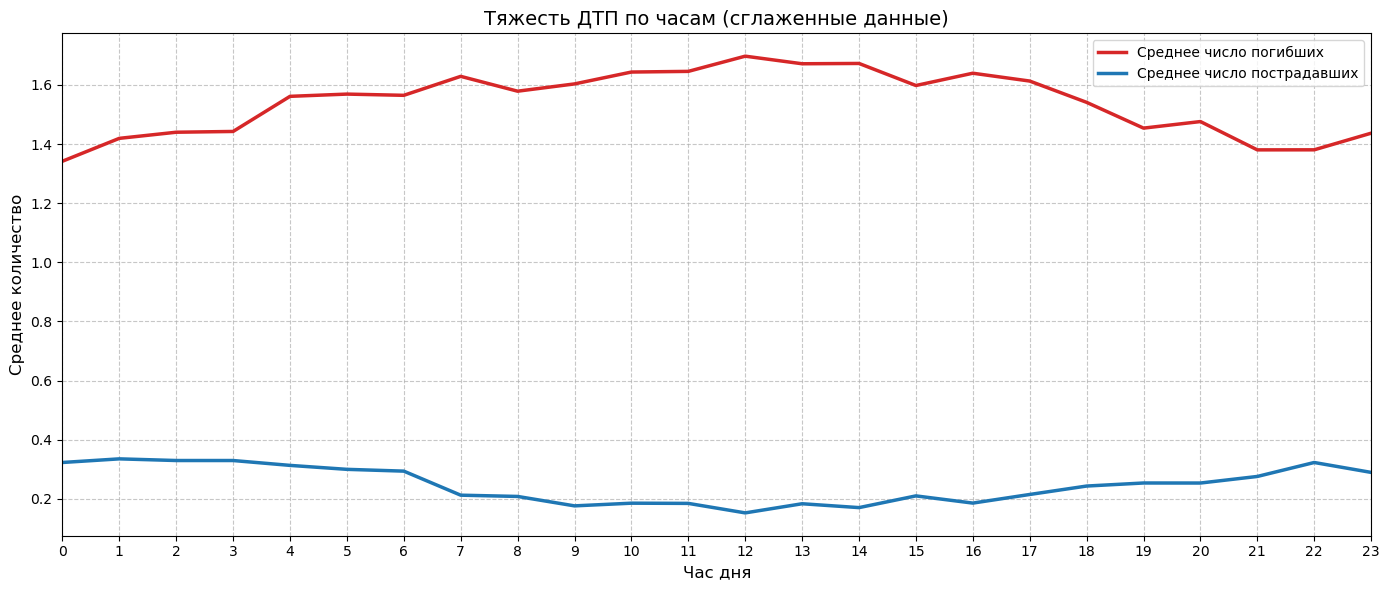

In [41]:
# 3. Тяжесть ДТП по часам
plt.figure(figsize=(14, 6))

# Группируем по часам и вычисляем средние значения
hourly_stats = df.groupby('hour').agg({
    'fatalities_amount': 'mean',
    'victims_amount': 'mean'
}).reset_index()

# Сглаживание данных для лучшей визуализации
# hourly_stats['fatalities_smooth'] = hourly_stats['fatalities_amount'].rolling(window=3, center=True).mean()
# hourly_stats['victims_smooth'] = hourly_stats['victims_amount'].rolling(window=3, center=True).mean()

# Строим график
ax3 = sns.lineplot(data=hourly_stats, x='hour', y='fatalities_amount', 
                  label='Среднее число погибших', color='#d62728', linewidth=2.5)
sns.lineplot(data=hourly_stats, x='hour', y='victims_amount', 
            label='Среднее число пострадавших', color='#1f77b4', linewidth=2.5)

plt.title('Тяжесть ДТП по часам (сглаженные данные)', fontsize=14)
plt.xlabel('Час дня', fontsize=12)
plt.ylabel('Среднее количество', fontsize=12)
plt.xticks(np.arange(0, 24, 1))
plt.xlim(0, 23)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Находим самый опасный час для погибших
max_fatal_hour = hourly_stats.loc[hourly_stats['fatalities_amount'].idxmax(), 'hour']
max_fatal_value = hourly_stats['fatalities_amount'].max()

# Добавляем аннотацию
# ax3.annotate(f'Пик: {max_fatal_value:.2f}', 
#              xy=(max_fatal_hour, max_fatal_value),
#              xytext=(max_fatal_hour, max_fatal_value + 0.05),
#              arrowprops=dict(facecolor='black', shrink=0.05),
#              horizontalalignment='center')

plt.tight_layout()
plt.show()

Ответьте на вопросы:

Какое время суток самое опасное (максимальное количествое ДТП)? 

Какой тип ДПТ стоит на втором месте по частоте появления? 

Какой час самый опасный на дорогах (максимальное среднее количество погибших)? 

In [26]:
# Ответы на вопросы:
print("\nОтветы на вопросы:")

# 1. Самое опасное время суток
most_dangerous_period = df['time_period'].value_counts().idxmax()
print(f"1. Самое опасное время суток: {most_dangerous_period}")

# 2. Тип ДТП на втором месте по частоте
second_common_type = df['category'].value_counts().index[1]
print(f"2. Тип ДТП на втором месте по частоте: {second_common_type}")

# 3. Самый опасный час (максимальное среднее количество погибших)
most_dangerous_hour = hourly_stats.loc[hourly_stats['fatalities_amount'].idxmax(), 'hour']
print(f"3. Самый опасный час: {most_dangerous_hour}:00-{most_dangerous_hour+1}:00")


Ответы на вопросы:
1. Самое опасное время суток: День (12-18)
2. Тип ДТП на втором месте по частоте: Наезд
3. Самый опасный час: 12:00-13:00


## Задание 5: Анализ ДТП по сезонам (зима, лето, весна, осень)

Выведите 4 диаграмм:
1. Круговая диаграмма среднего количества ДТП по временам года
2. Столбчатая диаграмма среднего количества погибших по временам года
3. Столбчатая диаграмма среднего количества пострадавших по временам года
4. Линейный график с помесячной статистикой количества ДТП





Анализ ДТП по сезонам (апрель 2018)


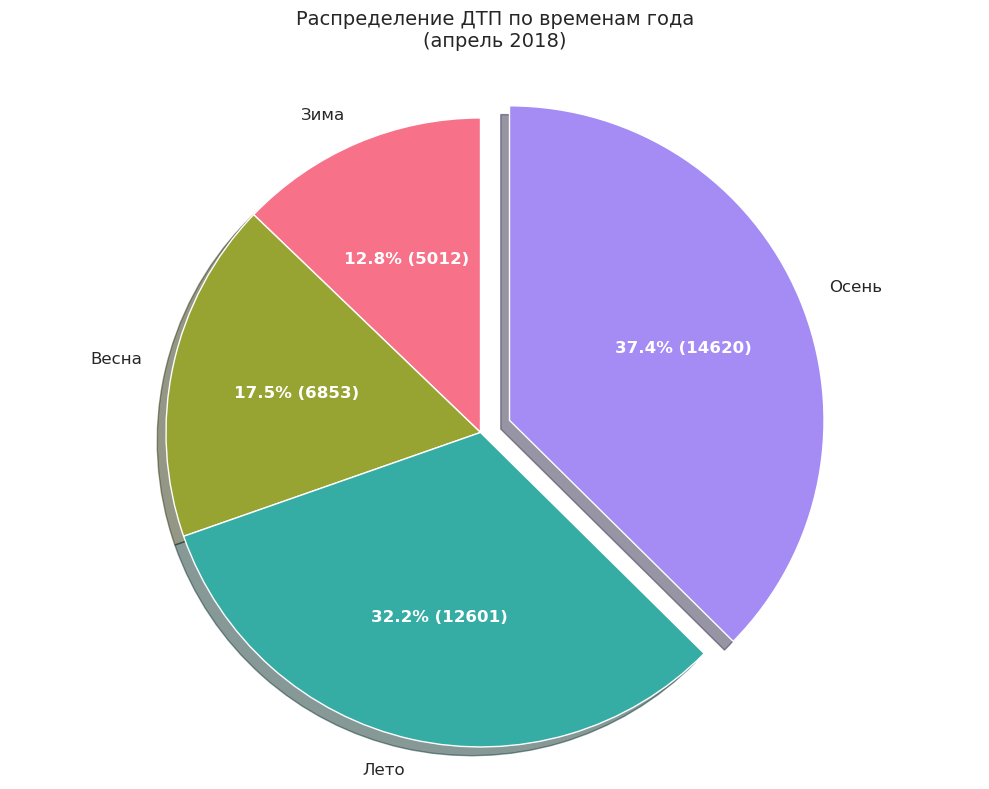

/tmp/ipykernel_486/90383366.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


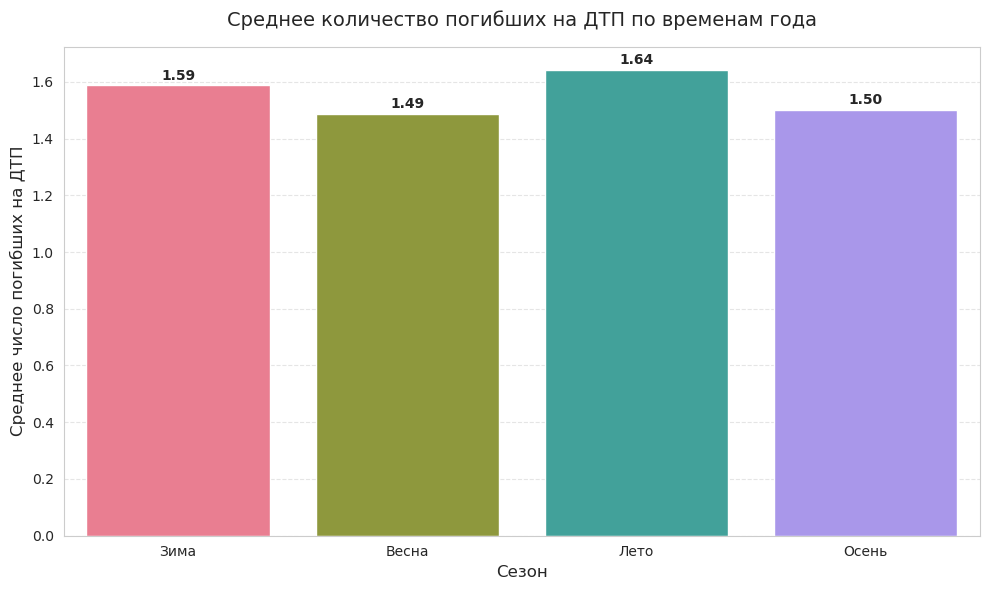

/tmp/ipykernel_486/90383366.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


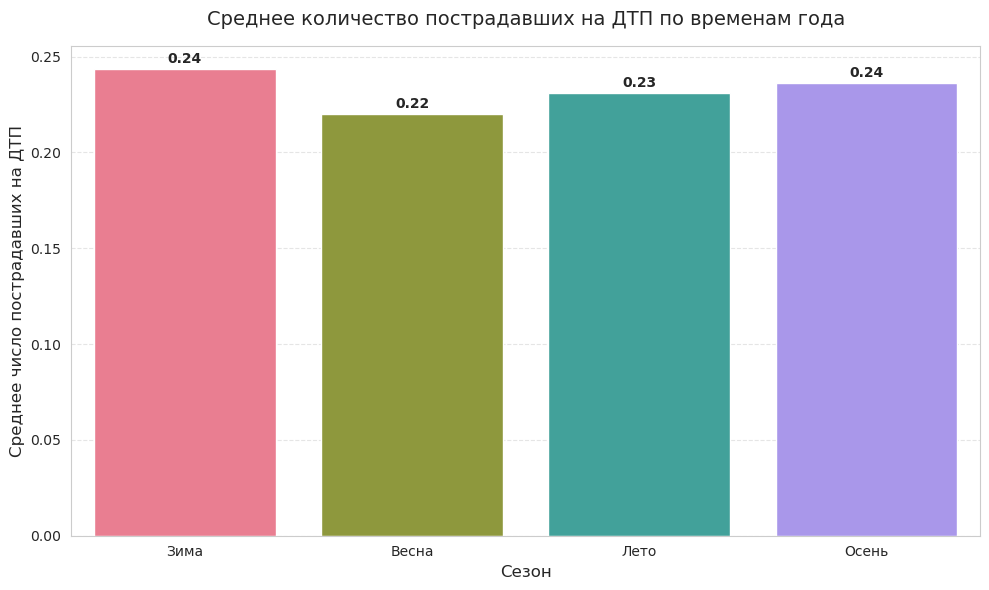

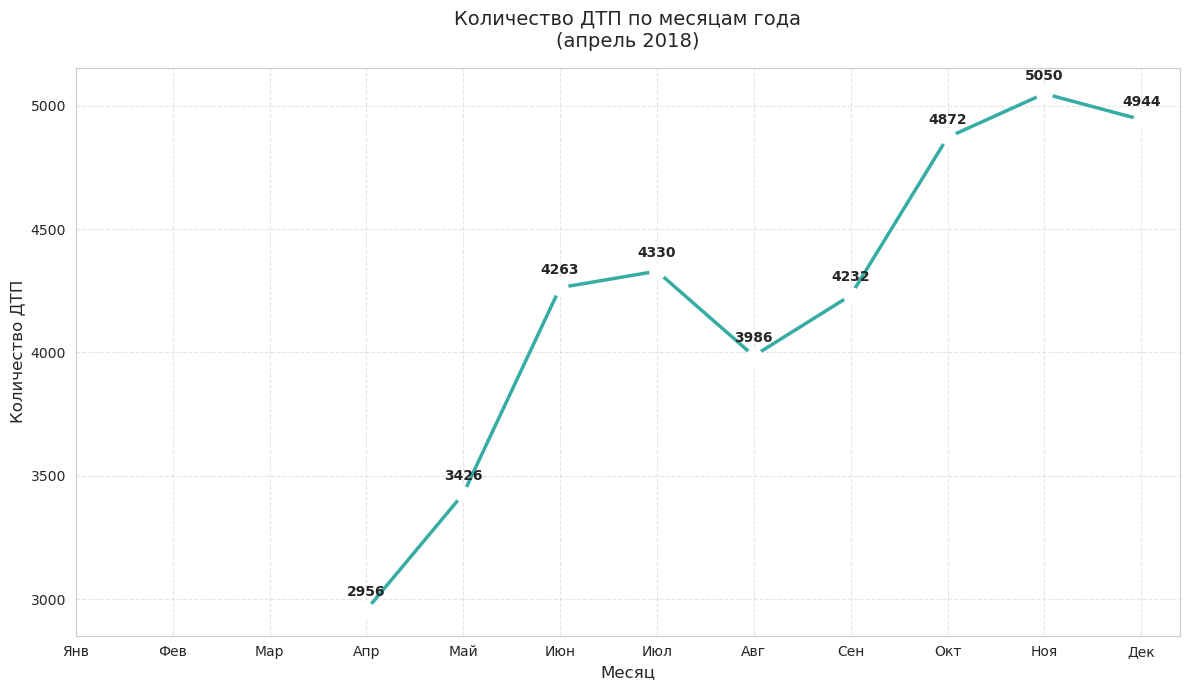


Выводы и ответы на вопросы:
1. Наибольшее количество ДТП происходит осень - 14620 случаев (37.4% от общего числа)
2. Тенденция по погибшим и пострадавшим различается:
   - Максимум погибших: Лето (1.64 на ДТП)
   - Максимум пострадавших: Зима (0.24 на ДТП)
3. Ограничения анализа:
   - Данные только за один месяц (апрель 2018)
   - Не учитываются региональные особенности
   - Для точных выводов нужны данные за несколько лет
   - Рекомендуется дополнить анализом других факторов (погода, праздники и т.д.)


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator

# 1. Загрузка и подготовка данных
def load_and_prepare_data():
    df = pd.read_csv('datasets/dtp201804.csv', encoding="utf-8", delimiter=";")
    
    # Преобразование даты и добавление временных характеристик
    df['crash_date'] = pd.to_datetime(df['crash_date'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['crash_date'])  # Удаляем строки с некорректными датами
    
    df['month'] = df['crash_date'].dt.month
    df['year'] = df['crash_date'].dt.year
    
    # Функция для определения сезона
    def get_season(month):
        try:
            month = int(month)
            if month in [12, 1, 2]:
                return 'Зима'
            elif month in [3, 4, 5]:
                return 'Весна'
            elif month in [6, 7, 8]:
                return 'Лето'
            elif month in [9, 10, 11]:
                return 'Осень'
            else:
                return 'Неизвестно'
        except:
            return 'Неизвестно'
    
    df['season'] = df['month'].apply(get_season)
    return df

df = load_and_prepare_data()

# 2. Настройки визуализации
sns.set_style("whitegrid")  # Используем современный стиль seaborn
sns.set_palette("husl")
season_order = ['Зима', 'Весна', 'Лето', 'Осень']
month_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
               'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

# 3. Функции для создания графиков
def create_pie_chart():
    plt.figure(figsize=(10, 8))
    season_counts = df['season'].value_counts().reindex(season_order)
    
    # Автоматическое выделение и цветовая схема
    explode = [0.1 if i == season_counts.idxmax() else 0 for i in season_counts.index]
    colors = sns.color_palette("husl", n_colors=4)
    
    patches, texts, autotexts = plt.pie(
        season_counts, 
        labels=season_counts.index, 
        autopct=lambda p: f'{p:.1f}% ({int(round(p*sum(season_counts)/100))})',
        startangle=90,
        explode=explode,
        colors=colors,
        shadow=True,
        textprops={'fontsize': 12}
    )
    
    # Улучшаем читаемость подписей
    for text in autotexts:
        text.set_color('white')
        text.set_fontweight('bold')
    
    plt.title('Распределение ДТП по временам года\n(апрель 2018)', fontsize=14, pad=20)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

def create_bar_chart(data, title, ylabel):
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x=data.index,
        y=data.values,
        order=season_order,
        palette=sns.color_palette("husl", n_colors=4),
        saturation=0.8
    )
    
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel('Сезон', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Добавляем подписи значений
    for p in ax.patches:
        ax.annotate(
            f'{p.get_height():.2f}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 7),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )
    
    plt.tight_layout()
    plt.show()

def create_monthly_line_chart():
    plt.figure(figsize=(12, 7))
    
    # Подсчет и сглаживание данных с обработкой пропусков
    monthly_stats = df.groupby('month').size()
    monthly_stats_smooth = monthly_stats.rolling(
        window=2,
        center=True,
        min_periods=1
    ).mean().fillna(0)  # Заполняем возможные NaN
    
    ax = sns.lineplot(
        x=monthly_stats_smooth.index,
        y=monthly_stats_smooth.values,
        color=sns.color_palette("husl")[3],
        linewidth=2.5,
        marker='o',
        markersize=10,
        markerfacecolor='white',
        markeredgewidth=2
    )
    
    plt.title('Количество ДТП по месяцам года\n(апрель 2018)', fontsize=14, pad=15)
    plt.xlabel('Месяц', fontsize=12)
    plt.ylabel('Количество ДТП', fontsize=12)
    plt.xticks(np.arange(1, 13, 1), [month_names[i] for i in range(12)])
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Добавляем подписи точек
    for month in monthly_stats_smooth.index:
        value = monthly_stats_smooth[month]
        if value > 0:  # Пропускаем нулевые значения
            ax.annotate(
                f"{int(round(value))}",
                (month, value),
                textcoords="offset points",
                xytext=(0,10),
                ha='center',
                fontsize=10,
                fontweight='bold'
            )
    
    plt.tight_layout()
    plt.show()

# 4. Создание всех графиков
print("\nАнализ ДТП по сезонам (апрель 2018)\n" + "="*40)

# 1. Круговая диаграмма распределения ДТП
create_pie_chart()

# 2. Столбчатая диаграмма среднего количества погибших
season_fatalities = df.groupby('season')['fatalities_amount'].mean().reindex(season_order)
create_bar_chart(
    season_fatalities,
    'Среднее количество погибших на ДТП по временам года',
    'Среднее число погибших на ДТП'
)

# 3. Столбчатая диаграмма среднего количества пострадавших
season_victims = df.groupby('season')['victims_amount'].mean().reindex(season_order)
create_bar_chart(
    season_victims,
    'Среднее количество пострадавших на ДТП по временам года',
    'Среднее число пострадавших на ДТП'
)

# 4. Линейный график помесячной статистики
create_monthly_line_chart()

# 5. Анализ и выводы
print("\nВыводы и ответы на вопросы:")

# 1. В какое время года самое большое количество ДТП?
season_counts = df['season'].value_counts().reindex(season_order)
max_season = season_counts.idxmax()
print(f"1. Наибольшее количество ДТП происходит {max_season.lower()} - {season_counts[max_season]} случаев "
      f"({season_counts[max_season]/season_counts.sum():.1%} от общего числа)")

# 2. Одинаковая ли тенденция по погибшим и пострадавшим?
fatal_season = season_fatalities.idxmax()
victim_season = season_victims.idxmax()
comparison = "совпадает" if fatal_season == victim_season else "различается"
print(f"2. Тенденция по погибшим и пострадавшим {comparison}:")
print(f"   - Максимум погибших: {fatal_season} ({season_fatalities[fatal_season]:.2f} на ДТП)")
print(f"   - Максимум пострадавших: {victim_season} ({season_victims[victim_season]:.2f} на ДТП)")

# 3. Надежность анализа
print("3. Ограничения анализа:")
print("   - Данные только за один месяц (апрель 2018)")
print("   - Не учитываются региональные особенности")
print("   - Для точных выводов нужны данные за несколько лет")
print("   - Рекомендуется дополнить анализом других факторов (погода, праздники и т.д.)")

Ответьте на вопросы:

В какое время года самое большое количество ДТП?

Одинаковая ли тенденция сезонности по параметрам среднее количество пострадавших и погибших?

Стоит ли доверять полученной аналитики по сезонам?